# Project 1: Data Analysis 

## Aggregate inflation in Denmark

1.1 Basic

In [56]:
import pandas as pd

url41 = "https://api.statbank.dk/v1/data/IFOR41/CSV?ULLIG=70&Tid=*"
gini = pd.read_csv(url41, sep=";")
gini.head()

url32 = "https://api.statbank.dk/v1/data/IFOR32/CSV?DECILGEN=*&Tid=*"
decile = pd.read_csv(url32, sep=";")
decile.head()

print(decile)


      DECILGEN   TID  INDHOLD
0     1. decil  1987    31418
1     1. decil  1988    32746
2     1. decil  1989    35284
3     1. decil  1990    36480
4     1. decil  1991    40715
..         ...   ...      ...
375  10. decil  2020   719999
376  10. decil  2021   779827
377  10. decil  2022   769052
378  10. decil  2023   834074
379  10. decil  2024   852980

[380 rows x 3 columns]


1.1 The Gini coeffient and the top 10 percent share

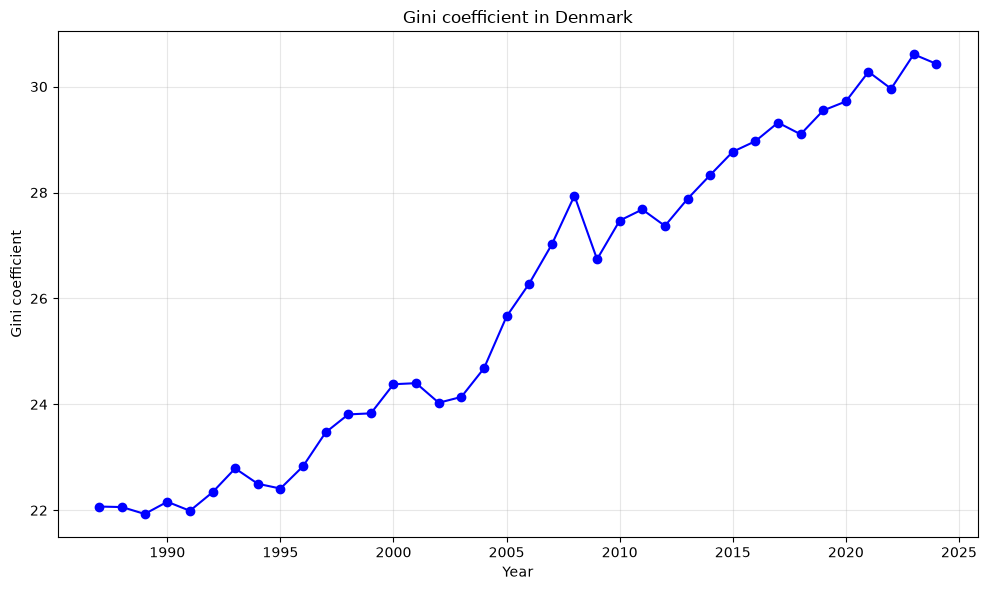

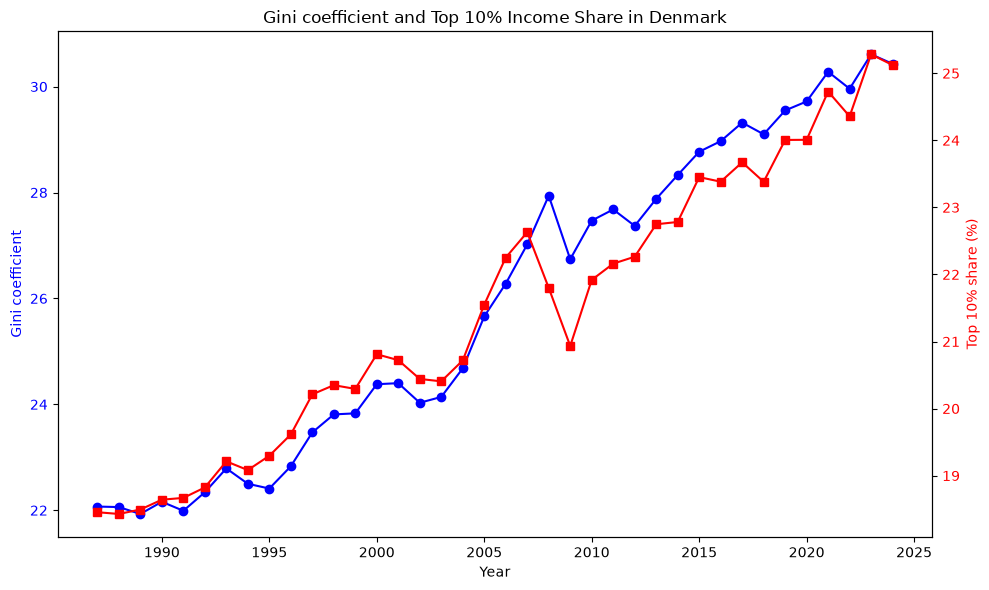

Correlation: 0.982


In [65]:
import pandas as pd
import matplotlib.pyplot as plt

url41 = "https://api.statbank.dk/v1/data/IFOR41/CSV?ULLIG=70&Tid=*"
gini = pd.read_csv(url41, sep=";")
gini.head()

url32 = "https://api.statbank.dk/v1/data/IFOR32/CSV?DECILGEN=*&Tid=*"
decile = pd.read_csv(url32, sep=";")
decile.head()

# Fjern whitespace i kolonnenavne
gini.columns = [col.strip() for col in gini.columns]
decile.columns = [col.strip() for col in decile.columns]

# Hvis kolonnenavne er TID og INDHOLD, brug dem
if "TID" in gini.columns and "INDHOLD" in gini.columns:
    gini = gini[["TID", "INDHOLD"]].copy()

    # Rens værdier
    gini["TID"] = pd.to_numeric(gini["TID"], errors="coerce")
    gini["INDHOLD"] = pd.to_numeric(
        gini["INDHOLD"].astype(str).str.replace(",", "."),
        errors="coerce"
    )

    gini = gini.dropna().sort_values("TID")

    Gini_fig = plt.figure(figsize=(10, 6))
    plt.plot(gini["TID"], gini["INDHOLD"], marker="o", color="blue")
    plt.title("Gini coefficient in Denmark")
    plt.xlabel("Year")
    plt.ylabel("Gini coefficient")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Kolonnerne ser ikke ud som forventet. Tjek df.columns.")
    print(gini.columns)

# Add the total share of the top 10% and bottom 10% to the plot
# Rens IFOR32-data
decile["TID"] = pd.to_numeric(decile["TID"], errors="coerce")
decile["INDHOLD"] = pd.to_numeric(decile["INDHOLD"], errors="coerce")

# Lav bred tabel med én kolonne pr. decil
decile_wide = decile.pivot(
    index="TID",
    columns="DECILGEN",
    values="INDHOLD"
)

# Top 10%-indkomst (10. decil)
top10_income = decile_wide["10. decil"]

# Samlet indkomst over alle deciler
total_income = decile_wide.sum(axis=1)

# Top 10%-andel
top10_share = top10_income / total_income

# Saml med Gini-data
gini_plot = gini.rename(columns={"INDHOLD": "GINI"})

df = pd.merge(
    gini_plot,
    top10_share.rename("TOP10_SHARE"),
    left_on="TID",
    right_index=True,
    how="inner"
)

# Figur med to y-akser
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(
    df["TID"],
    df["GINI"],
    color="blue",
    marker="o",
    label="Gini coefficient"
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Gini coefficient", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()

ax2.plot(
    df["TID"],
    df["TOP10_SHARE"] * 100,
    color="red",
    marker="s",
    label="Top 10% share"
)

ax2.set_ylabel("Top 10% share (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Gini coefficient and Top 10% Income Share in Denmark")

fig.tight_layout()
plt.show()

# Korrelation
corr = df["GINI"].corr(df["TOP10_SHARE"])
print(f"Correlation: {corr:.3f}")

# 2.1 Prediction




1.2 Prection

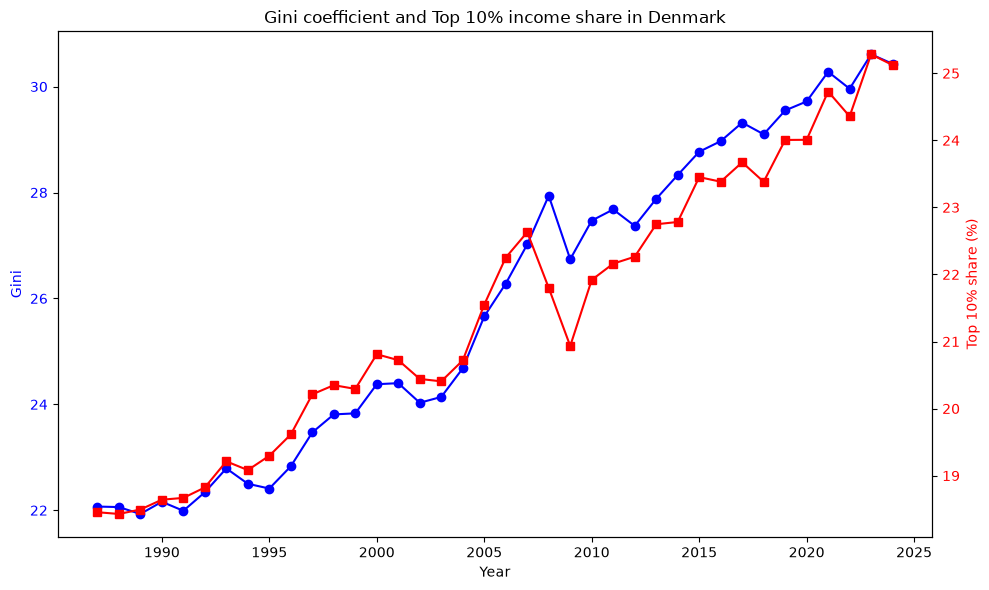

Correlation: 0.982
Linear coefficients:
beta0 = 21.0428
beta1 = 0.2635
Quadratic coefficients:
beta0 = 21.3042
beta1 = 0.2200
beta2 = 0.001178
Year 2030: linear = 32.375, quadratic = 32.941
Year 2040: linear = 35.011, quadratic = 36.271


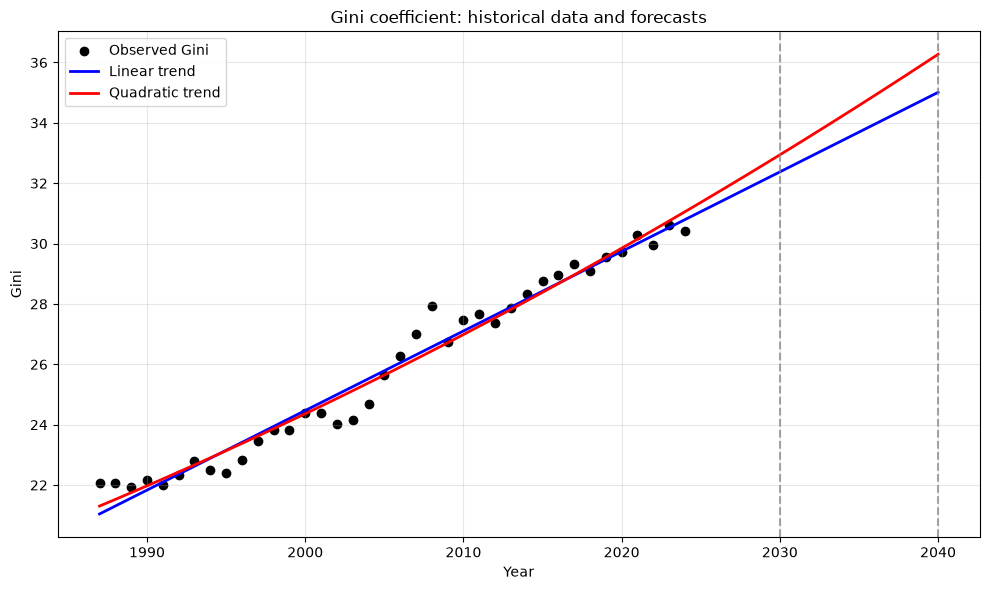

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -------------------------------------------------
# 1.1: Gini + Top 10% share
# -------------------------------------------------

url41 = "https://api.statbank.dk/v1/data/IFOR41/CSV?ULLIG=70&Tid=*"
gini = pd.read_csv(url41, sep=";")
gini = gini[["TID", "INDHOLD"]].copy()
gini.columns = ["Year", "Gini"]

gini["Year"] = pd.to_numeric(gini["Year"], errors="coerce")
gini["Gini"] = pd.to_numeric(gini["Gini"].astype(str).str.replace(",", "."), errors="coerce")
gini = gini.dropna().sort_values("Year").reset_index(drop=True)

url32 = "https://api.statbank.dk/v1/data/IFOR32/CSV?DECILGEN=*&Tid=*"
decile = pd.read_csv(url32, sep=";")
decile = decile[["DECILGEN", "TID", "INDHOLD"]].copy()
decile.columns = ["decile", "Year", "income"]

decile["Year"] = pd.to_numeric(decile["Year"], errors="coerce")
decile["income"] = pd.to_numeric(decile["income"].astype(str).str.replace(",", "."), errors="coerce")

# "10. decil" -> 10
decile["decile"] = decile["decile"].astype(str).str.extract(r"(\d+)")
decile["decile"] = pd.to_numeric(decile["decile"], errors="coerce")

decile = decile.dropna().sort_values(["Year", "decile"]).reset_index(drop=True)

decile_pivot = decile.pivot_table(
    index="Year",
    columns="decile",
    values="income",
    aggfunc="first"
).sort_index()

decile_pivot = decile_pivot.reindex(columns=range(1, 11), fill_value=np.nan)
top10_share = decile_pivot[10] / decile_pivot.sum(axis=1)

top10 = top10_share.reset_index()
top10.columns = ["Year", "Top10Share"]

merged = gini.merge(top10, on="Year", how="inner")

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(merged["Year"], merged["Gini"], color="blue", marker="o", label="Gini")
ax1.set_xlabel("Year")
ax1.set_ylabel("Gini", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(merged["Year"], merged["Top10Share"] * 100, color="red", marker="s", label="Top 10% share")
ax2.set_ylabel("Top 10% share (%)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Gini coefficient and Top 10% income share in Denmark")
plt.tight_layout()
plt.show()

corr = merged["Gini"].corr(merged["Top10Share"])
print(f"Correlation: {corr:.3f}")

# -------------------------------------------------
# 1.2: Minimize SSE yourself with scipy.optimize.minimize
# -------------------------------------------------

gini_fit = gini.copy()
gini_fit["t"] = gini_fit["Year"] - gini_fit["Year"].min()

t = gini_fit["t"].to_numpy()
y = gini_fit["Gini"].to_numpy()

# Linear trend
def sse_linear(beta, t, y):
    y_hat = beta[0] + beta[1] * t
    return np.sum((y - y_hat) ** 2)

result_linear = minimize(
    sse_linear,
    x0=[20, 0.1],
    args=(t, y)
)

beta_linear = result_linear.x
print("Linear coefficients:")
print(f"beta0 = {beta_linear[0]:.4f}")
print(f"beta1 = {beta_linear[1]:.4f}")

# Quadratic trend
def sse_quadratic(beta, t, y):
    y_hat = beta[0] + beta[1] * t + beta[2] * t**2
    return np.sum((y - y_hat) ** 2)

result_quadratic = minimize(
    sse_quadratic,
    x0=[20, 0.1, 0.001],
    args=(t, y)
)

beta_quadratic = result_quadratic.x
print("Quadratic coefficients:")
print(f"beta0 = {beta_quadratic[0]:.4f}")
print(f"beta1 = {beta_quadratic[1]:.4f}")
print(f"beta2 = {beta_quadratic[2]:.6f}")

# Forecasts for 2030 and 2040
for year in [2030, 2040]:
    tau = year - gini_fit["Year"].min()
    lin_pred = beta_linear[0] + beta_linear[1] * tau
    quad_pred = beta_quadratic[0] + beta_quadratic[1] * tau + beta_quadratic[2] * tau**2
    print(f"Year {year}: linear = {lin_pred:.3f}, quadratic = {quad_pred:.3f}")

# Plot observed data + fitted trends
years_future = np.arange(gini_fit["Year"].min(), 2041)
t_future = years_future - gini_fit["Year"].min()

linear_fit = beta_linear[0] + beta_linear[1] * t_future
quadratic_fit = beta_quadratic[0] + beta_quadratic[1] * t_future + beta_quadratic[2] * t_future**2

plt.figure(figsize=(10, 6))
plt.scatter(gini_fit["Year"], gini_fit["Gini"], color="black", label="Observed Gini")
plt.plot(years_future, linear_fit, color="blue", linewidth=2, label="Linear trend")
plt.plot(years_future, quadratic_fit, color="red", linewidth=2, label="Quadratic trend")
plt.axvline(2030, color="gray", linestyle="--", alpha=0.7)
plt.axvline(2040, color="gray", linestyle="--", alpha=0.7)
plt.title("Gini coefficient: historical data and forecasts")
plt.xlabel("Year")
plt.ylabel("Gini")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()